In [1]:
import numpy as np
from IPython.display import display, Image
import matplotlib.pyplot as plt
from numpy.linalg import solve
import warnings
warnings.filterwarnings('ignore')

#### Ejercicio 4: El proceso de la glucólisis

La glucólisis es el proceso bioquímico que permite oxidar la glucosa para extraer de ella energía y puede ser modelado por las ecuaciones:

$$\frac{\text{d}x}{\text{d}t}=-x+ay+x^2y,\quad \frac{\text{d}y}{\text{d}t}=b-ay-x^2y,$$

donde $x$ y $y$ representan la concentración de los compuestos adenosín difosfato (ADP) y fructosa-6-fosfato (F6P o éster de Neuberg).

Este tipo de ecuaciones vienen caracterizadas por los puntos estacionarios, aquellos en los que las derivadas con respecto a todas las variables son cero, y a partir de los cuales las ecuaciones no cambian. 

Los puntos estacionarios de nuestro modelo para glucólisis vienen dados por:

$$0=-x+ay+x^2y,\quad 0=b-ay-x^2y.$$

---
1. Obtener los valores de los puntos estacionarios.

---

*Respuesta*: despejando las ecuaciones de los puntos estacionarios se obtiene la condición del enunciado (x = b).

$$x=y\,(a+x^2),\quad y=\frac{b}{a+x^2}.$$

---
2. Escribir un programa para obtener la solución de la glucólisis en los puntos estacionarios usando el método del punto fijo.   
   Aplicarlo para $a=1$ y $b=2$. ¿Converge?.

---

*Respuesta*: Se puede observar que el sistema no converge.

In [2]:
def f(x):
    a = 1
    b = 2
    return np.array([x[1]*(a + x[0]**2), b/(a + x[0]**2)], float)

x0 = np.array([1., 1.], float)
it = 0
err = np.array([1., 1.], float)
eps = 1e-4
for maxiter in [100, 1000, 10000, 100000]:
    while max(err) > eps and it < maxiter: #and err[1] > eps:
        x1 = f(x0)
        err = abs(x1 - x0)
        x0 = x1
        it += 1
    print(f"x = {x1[0]}, y = {x1[1]} | iter = {it}")

x = 2.718690516444634, y = 1.4712371731156297 | iter = 100
x = 0.07572966073056349, y = 1.9954771694648552 | iter = 1000
x = 0.6220034419136329, y = 1.9999248906639715 | iter = 10000
x = 36.48758643981729, y = 0.012867859852177671 | iter = 100000


3. Reordenar la ecuaciones de una forma alternativa de forma que el método sea ahora convergente.

---

*Respuesta*: para que el sistema converja es necesario utilizar las siguientes ecuaciones.

$$x=\sqrt{\frac{b - ay}{y}},\quad y=\frac{x}{a+x^2}.$$

x = 1.9999980105621866, y = 0.40000023873260093 | iter = 27
x = 1.9999980105621866, y = 0.40000023873260093 | iter = 27
x = 1.9999980105621866, y = 0.40000023873260093 | iter = 27
x = 1.9999980105621866, y = 0.40000023873260093 | iter = 27


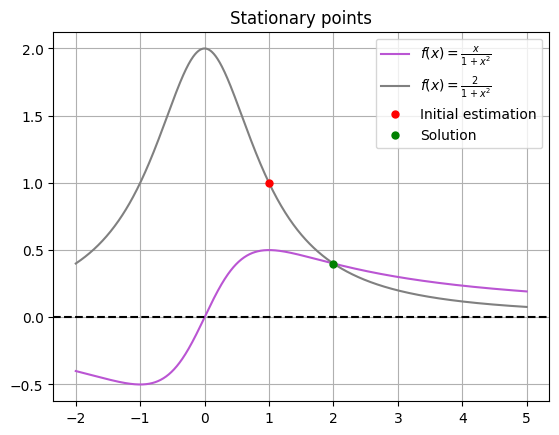

In [3]:
def f(x):
    a = 1
    b = 2
    return np.array([np.sqrt((b - a*x[1])/x[1]), x[0]/(a + x[0]**2)], float)

x0 = np.array([1., 1.], float)
it = 0
err = np.array([1., 1.], float)
eps = 1e-6
for maxiter in [100, 1000, 10000, 100000]:
    while max(err) > eps and it < maxiter: #and err[1] > eps:
        x1 = f(x0)
        err = abs(x1 - x0)
        x0 = x1
        it += 1
    print(f"x = {x1[0]}, y = {x1[1]} | iter = {it}")


def f1(x):
    return x/(1 + x**2)
def f2(x):
    return 2/(1 + x**2)

x = np.linspace(-2, 5, 1000)
y = np.linspace(-2, 5, 1000)

plt.plot(x, f1(x), color = 'mediumorchid', label = "$f(x) = \\frac{x}{1+x^2}$")
plt.plot(x, f2(x), color = 'gray', label = "$f(x) = \\frac{2}{1+x^2}$")
plt.grid()
plt.title('Stationary points')
plt.axhline(0, color = 'k', linestyle = '--')
plt.plot(1, 1, 'r.', markersize=10, label = 'Initial estimation')
plt.plot(x1[0], x1[1], 'g.', markersize=10, label = 'Solution')
plt.legend()
plt.show()
